# DOS vs Vanilla: Coverage, Ordering, and Task Fit

This notebook focuses on the specific question raised by the saved subset results:

- Is `dos_rag` effectively acting like long-context on some tasks?
- If DOS and vanilla already cover nearly the same document content, is the remaining difference mostly **ordering**?
- Which prompt / task types seem to favor `dos_rag`, `vanilla_rag`, or `raptor`?

Important scope note:

- I did **not** find a separate saved `long_context` benchmark output in the repo, so this notebook does **not** claim a direct measured comparison against an LC baseline.
- Instead, it measures how close the saved `dos_rag` / `vanilla_rag` contexts are to **whole-document coverage**, and how strongly their **prompt order** differs.
- For `raptor`, the fairest comparison remains the shared 15-example overlap, because the saved RAPTOR subset run is smaller.


In [1]:
from pathlib import Path
import json
import sys
from statistics import mean, median

import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ModuleNotFoundError:
    def display(obj):
        print(obj)


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "benchmarking").exists() and (candidate / "outputs/subset/meeting_core").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repo root from the current working directory.")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from benchmarking.metrics import compute_metrics
from benchmarking.config import TASK_TYPE

CORE_ROOT = ROOT / "outputs/subset/meeting_core" / "subset"
RAPTOR_ROOT = ROOT / "outputs/subset/meeting_raptor15" / "subset"

TASK_LABELS = {
    "qmsum": "query-focused meeting summarization",
    "qasper": "scientific paper QA",
    "narrative_qa": "narrative reading comprehension",
    "quality": "multiple-choice long reading comprehension",
    "contract_nli": "legal clause-level NLI",
}

TASK_NOTES = {
    "qmsum": "long abstractive answer against a meeting transcript",
    "qasper": "short factual / span-like answer from a paper",
    "narrative_qa": "entity/location/story-state tracking",
    "quality": "exact option text from a long story",
    "contract_nli": "exact label over contract evidence",
}


def load_json(path):
    with open(path) as fh:
        return json.load(fh)


def load_jsonl(path):
    rows = []
    with open(path) as fh:
        for line in fh:
            if line.strip():
                rows.append(json.loads(line))
    return rows


def task_score(task, row):
    return compute_metrics([row.get("prediction", "")], [row.get("references", [])], task_name=task).get("scrolls_score", 0.0)


def selected_chunk_table(row):
    by_index = {chunk["index"]: chunk for chunk in row.get("retrieved_chunks", [])}
    rows = []
    for prompt_pos, chunk_index in enumerate(row.get("selected_chunk_indices", []), start=1):
        chunk = by_index.get(chunk_index)
        if not chunk:
            continue
        if chunk.get("start_token") is None or chunk.get("end_token") is None:
            continue
        rows.append(
            {
                "prompt_pos": prompt_pos,
                "chunk_index": chunk_index,
                "retrieval_rank": chunk.get("rank"),
                "start_token": int(chunk["start_token"]),
                "end_token": int(chunk["end_token"]),
                "token_count": int(chunk.get("token_count") or max(0, int(chunk["end_token"]) - int(chunk["start_token"]))),
                "score": chunk.get("score"),
                "chunk_text": chunk.get("chunk", ""),
            }
        )
    return pd.DataFrame(rows)


def merge_intervals(intervals):
    cleaned = sorted((int(s), int(e)) for s, e in intervals if e > s)
    merged = []
    for start, end in cleaned:
        if not merged or start > merged[-1][1]:
            merged.append([start, end])
        else:
            merged[-1][1] = max(merged[-1][1], end)
    return [(start, end) for start, end in merged]


def interval_length(intervals):
    return sum(end - start for start, end in merge_intervals(intervals))


def interval_intersection_length(a, b):
    a = merge_intervals(a)
    b = merge_intervals(b)
    i = j = 0
    total = 0
    while i < len(a) and j < len(b):
        start = max(a[i][0], b[j][0])
        end = min(a[i][1], b[j][1])
        if end > start:
            total += end - start
        if a[i][1] < b[j][1]:
            i += 1
        else:
            j += 1
    return total


def token_coverage(row):
    table = selected_chunk_table(row)
    intervals = list(zip(table["start_token"], table["end_token"]))
    covered = interval_length(intervals)
    total = int(row.get("document_tokens") or 0)
    ratio = covered / total if total else 0.0
    return {
        "covered_tokens": covered,
        "document_tokens": total,
        "coverage_ratio": ratio,
        "intervals": merge_intervals(intervals),
    }


def coverage_iou(row_a, row_b):
    cov_a = token_coverage(row_a)
    cov_b = token_coverage(row_b)
    union = interval_length(cov_a["intervals"] + cov_b["intervals"])
    if union == 0:
        return 1.0
    inter = interval_intersection_length(cov_a["intervals"], cov_b["intervals"])
    return inter / union


def document_order_score(row):
    table = selected_chunk_table(row)
    n = len(table)
    if n <= 1:
        return 1.0

    start_tokens = table["start_token"].tolist()
    sorted_positions = sorted(range(n), key=lambda i: start_tokens[i])
    prompt_to_doc_rank = {prompt_pos: doc_rank for doc_rank, prompt_pos in enumerate(sorted_positions)}
    mean_abs_disp = sum(abs(i - prompt_to_doc_rank[i]) for i in range(n)) / n
    max_mean_abs_disp = (n - 1) / 2 if n > 1 else 1.0
    normalized_disp = mean_abs_disp / max_mean_abs_disp if max_mean_abs_disp else 0.0
    return 1.0 - normalized_disp


def classify_regime(v_cov, d_cov, vd_iou):
    min_cov = min(v_cov, d_cov)
    if vd_iou >= 0.95 and min_cov >= 0.95:
        return "near-full shared document coverage; mostly an ordering comparison"
    if vd_iou >= 0.95 and min_cov >= 0.80:
        return "high shared coverage; ordering dominates more than retrieval coverage"
    if vd_iou >= 0.70:
        return "partial shared coverage; both retrieval coverage and ordering matter"
    return "substantial coverage differences; retrieval differences matter"


print("Repo root:", ROOT)
print("Core subset:", CORE_ROOT)
print("RAPTOR subset:", RAPTOR_ROOT)


Repo root: /home/yifan/FORWARD Data Lab/long-document-qa-baseline
Core subset: /home/yifan/FORWARD Data Lab/long-document-qa-baseline/outputs/subset/meeting_core/subset
RAPTOR subset: /home/yifan/FORWARD Data Lab/long-document-qa-baseline/outputs/subset/meeting_raptor15/subset


## 1. How much of the document does each method actually feed?

The table below measures four separate things for `vanilla_rag` vs `dos_rag` on the saved 50-example subset:

- `selected_chunk_ratio`: fraction of each method's own chunks that entered the prompt
- `token_coverage_ratio`: approximate fraction of document tokens covered by the selected prompt chunks
- `coverage_iou`: token-span overlap between DOS and vanilla selected context
- `document_order_score`: how close the prompt order is to original document order

Interpretation guide:

- a `coverage_iou` near `1.0` means the two prompts cover almost the same document content
- a DOS `document_order_score` of `1.0` means the prompt is exactly in document order
- a low vanilla `document_order_score` means the prompt is heavily scrambled relative to document order


In [2]:
coverage_rows = []

for task in ["qmsum", "qasper", "narrative_qa", "quality", "contract_nli"]:
    vanilla_rows = {row["id"]: row for row in load_jsonl(CORE_ROOT / "vanilla_rag" / task / "results.jsonl")}
    dos_rows = {row["id"]: row for row in load_jsonl(CORE_ROOT / "dos_rag" / task / "results.jsonl")}
    shared_ids = sorted(set(vanilla_rows) & set(dos_rows))

    per_example = []
    for example_id in shared_ids:
        v_row = vanilla_rows[example_id]
        d_row = dos_rows[example_id]
        v_cov = token_coverage(v_row)
        d_cov = token_coverage(d_row)
        per_example.append(
            {
                "task": task,
                "id": example_id,
                "vanilla_selected_chunk_ratio": len(v_row.get("selected_chunk_indices", [])) / max(1, v_row.get("num_chunks", 1)),
                "dos_selected_chunk_ratio": len(d_row.get("selected_chunk_indices", [])) / max(1, d_row.get("num_chunks", 1)),
                "vanilla_token_coverage_ratio": min(1.0, v_cov["coverage_ratio"]),
                "dos_token_coverage_ratio": min(1.0, d_cov["coverage_ratio"]),
                "coverage_iou": coverage_iou(v_row, d_row),
                "vanilla_document_order_score": document_order_score(v_row),
                "dos_document_order_score": document_order_score(d_row),
                "vanilla_all_chunks": int(len(v_row.get("selected_chunk_indices", [])) == v_row.get("num_chunks", 0)),
                "dos_all_chunks": int(len(d_row.get("selected_chunk_indices", [])) == d_row.get("num_chunks", 0)),
            }
        )

    per_example_df = pd.DataFrame(per_example)
    coverage_rows.append(
        {
            "task": task,
            "task_label": TASK_LABELS[task],
            "task_type": TASK_TYPE[task],
            "vanilla_selected_chunk_ratio_mean": round(per_example_df["vanilla_selected_chunk_ratio"].mean(), 4),
            "dos_selected_chunk_ratio_mean": round(per_example_df["dos_selected_chunk_ratio"].mean(), 4),
            "vanilla_token_coverage_mean": round(per_example_df["vanilla_token_coverage_ratio"].mean(), 4),
            "dos_token_coverage_mean": round(per_example_df["dos_token_coverage_ratio"].mean(), 4),
            "coverage_iou_mean": round(per_example_df["coverage_iou"].mean(), 4),
            "vanilla_document_order_score_mean": round(per_example_df["vanilla_document_order_score"].mean(), 4),
            "dos_document_order_score_mean": round(per_example_df["dos_document_order_score"].mean(), 4),
            "vanilla_all_chunks_count": int(per_example_df["vanilla_all_chunks"].sum()),
            "dos_all_chunks_count": int(per_example_df["dos_all_chunks"].sum()),
            "num_examples": len(per_example_df),
            "interpretation": classify_regime(
                per_example_df["vanilla_token_coverage_ratio"].mean(),
                per_example_df["dos_token_coverage_ratio"].mean(),
                per_example_df["coverage_iou"].mean(),
            ),
        }
    )

coverage_summary_df = pd.DataFrame(coverage_rows)
display(coverage_summary_df)


,task,task_label,task_type,vanilla_selected_chunk_ratio_mean,dos_selected_chunk_ratio_mean,vanilla_token_coverage_mean,dos_token_coverage_mean,coverage_iou_mean,vanilla_document_order_score_mean,dos_document_order_score_mean,vanilla_all_chunks_count,dos_all_chunks_count,num_examples,interpretation
0,qmsum,query-focused meeting summarization,query_summarization,0.8893,0.8890,0.8887,0.8881,0.9686,0.3346,1.0,25,25,50,high shared coverage; ordering dominates more ...
1,qasper,scientific paper QA,question_answering,1.0000,1.0000,0.9998,0.9806,0.9769,0.2885,1.0,50,50,50,near-full shared document coverage; mostly an ...
2,narrative_qa,narrative reading comprehension,question_answering,0.3311,0.3318,0.3221,0.3221,0.5359,0.3322,1.0,0,0,50,substantial coverage differences; retrieval di...
3,quality,multiple-choice long reading comprehension,multiple_choice,1.0000,1.0000,0.9574,0.9661,0.9910,0.3556,1.0,50,50,50,near-full shared document coverage; mostly an ...
4,contract_nli,legal clause-level NLI,nli,1.0000,1.0000,1.0000,0.9957,0.9897,0.4007,1.0,50,50,50,near-full shared document coverage; mostly an ...


## 2. Coverage and Order Visualization

These plots separate two questions that are easy to mix together:

1. **Coverage**: are DOS and vanilla actually feeding the model different document content?
2. **Order**: even when coverage is similar, is the prompt arranged differently enough to matter?


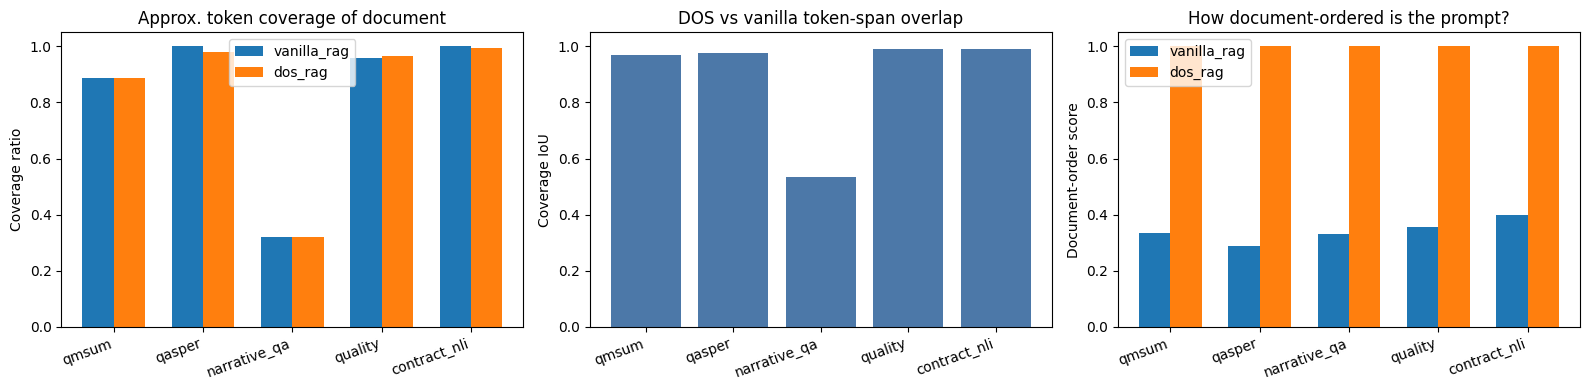

In [3]:
tasks = coverage_summary_df["task"].tolist()
x = range(len(tasks))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar([i - width / 2 for i in x], coverage_summary_df["vanilla_token_coverage_mean"], width=width, label="vanilla_rag")
axes[0].bar([i + width / 2 for i in x], coverage_summary_df["dos_token_coverage_mean"], width=width, label="dos_rag")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(tasks, rotation=20, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Approx. token coverage of document")
axes[0].set_ylabel("Coverage ratio")
axes[0].legend()

axes[1].bar(list(x), coverage_summary_df["coverage_iou_mean"], color="#4c78a8")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(tasks, rotation=20, ha="right")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("DOS vs vanilla token-span overlap")
axes[1].set_ylabel("Coverage IoU")

axes[2].bar([i - width / 2 for i in x], coverage_summary_df["vanilla_document_order_score_mean"], width=width, label="vanilla_rag")
axes[2].bar([i + width / 2 for i in x], coverage_summary_df["dos_document_order_score_mean"], width=width, label="dos_rag")
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(tasks, rotation=20, ha="right")
axes[2].set_ylim(0, 1.05)
axes[2].set_title("How document-ordered is the prompt?")
axes[2].set_ylabel("Document-order score")
axes[2].legend()

plt.tight_layout()
plt.show()


## 3. Representative Ordering Plots

The plots below show prompt position against normalized document start position for selected chunks.

How to read them:

- a near-diagonal line means the prompt follows document order
- a jagged or scrambled line means the model sees the same document pieces in a very different sequence

These examples are drawn from saved outputs and chosen to cover both "ordering helps" and "ordering is not enough" cases.


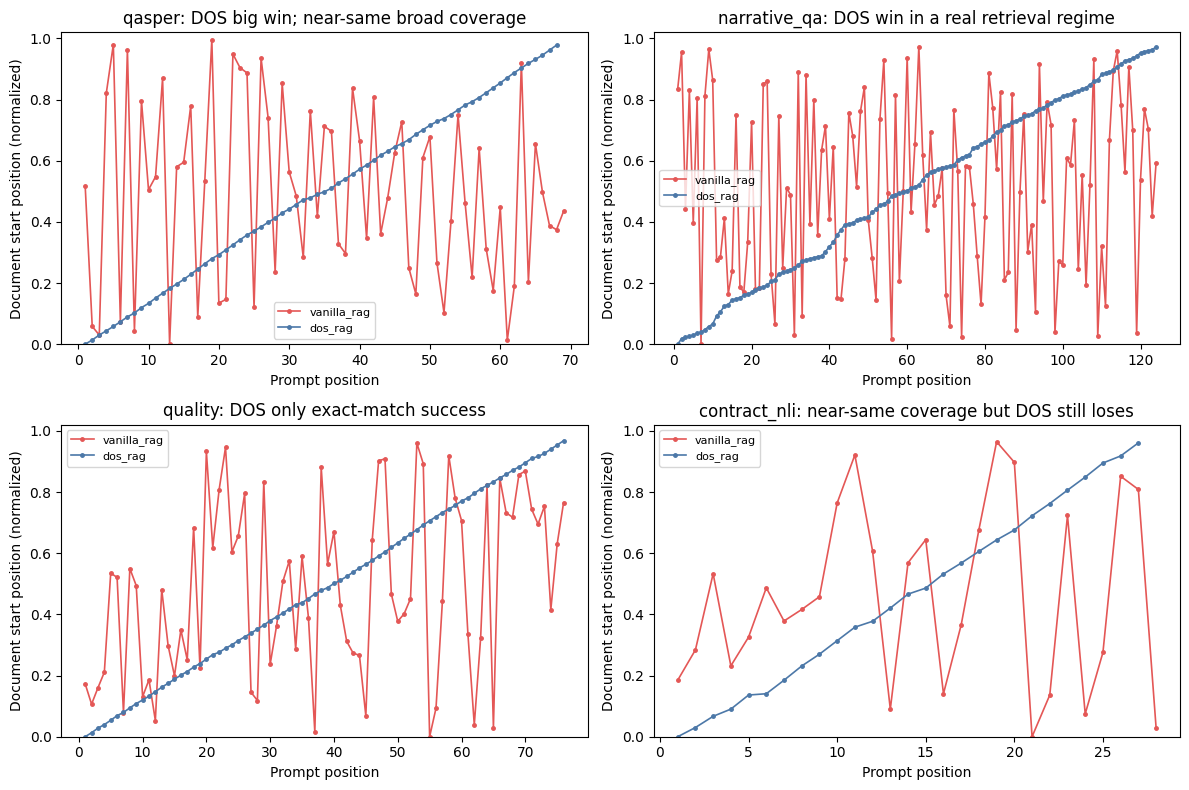

In [4]:
REPRESENTATIVE_EXAMPLES = {
    "qasper": ("a87a009c242d57c51fc94fe312af5e02070f898b", "DOS big win; near-same broad coverage"),
    "narrative_qa": ("8cb9a3afd8d542c798c3a34fd1a9afa0a77931c2_21", "DOS win in a real retrieval regime"),
    "quality": ("52845_75VB1ISR_3", "DOS only exact-match success"),
    "contract_nli": ("3_nda-1", "near-same coverage but DOS still loses"),
}


def plot_order_example(ax, task, example_id, label):
    v_rows = {row["id"]: row for row in load_jsonl(CORE_ROOT / "vanilla_rag" / task / "results.jsonl")}
    d_rows = {row["id"]: row for row in load_jsonl(CORE_ROOT / "dos_rag" / task / "results.jsonl")}
    v_row = v_rows[example_id]
    d_row = d_rows[example_id]

    for method, row, color in [
        ("vanilla_rag", v_row, "#e45756"),
        ("dos_rag", d_row, "#4c78a8"),
    ]:
        table = selected_chunk_table(row)
        if table.empty:
            continue
        xs = table["prompt_pos"].tolist()
        ys = [value / max(1, row.get("document_tokens", 1)) for value in table["start_token"].tolist()]
        ax.plot(xs, ys, marker="o", markersize=2.5, linewidth=1.2, label=method, color=color)

    ax.set_title(f"{task}: {label}")
    ax.set_xlabel("Prompt position")
    ax.set_ylabel("Document start position (normalized)")
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=8)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (task, (example_id, label)) in zip(axes.flatten(), REPRESENTATIVE_EXAMPLES.items()):
    plot_order_example(ax, task, example_id, label)

plt.tight_layout()
plt.show()


## 4. Example-Level Coverage and Ordering Summary

This table makes the same examples above easier to read numerically.


In [5]:
example_rows = []
for task, (example_id, label) in REPRESENTATIVE_EXAMPLES.items():
    v_rows = {row["id"]: row for row in load_jsonl(CORE_ROOT / "vanilla_rag" / task / "results.jsonl")}
    d_rows = {row["id"]: row for row in load_jsonl(CORE_ROOT / "dos_rag" / task / "results.jsonl")}
    v_row = v_rows[example_id]
    d_row = d_rows[example_id]
    example_rows.append(
        {
            "task": task,
            "example_id": example_id,
            "case": label,
            "vanilla_score": round(task_score(task, v_row), 4),
            "dos_score": round(task_score(task, d_row), 4),
            "vanilla_prediction": v_row.get("prediction", "")[:120],
            "dos_prediction": d_row.get("prediction", "")[:120],
            "vanilla_coverage": round(min(1.0, token_coverage(v_row)["coverage_ratio"]), 4),
            "dos_coverage": round(min(1.0, token_coverage(d_row)["coverage_ratio"]), 4),
            "coverage_iou": round(coverage_iou(v_row, d_row), 4),
            "vanilla_document_order_score": round(document_order_score(v_row), 4),
            "dos_document_order_score": round(document_order_score(d_row), 4),
        }
    )

example_summary_df = pd.DataFrame(example_rows)
display(example_summary_df)


,task,example_id,case,vanilla_score,dos_score,vanilla_prediction,dos_prediction,vanilla_coverage,dos_coverage,coverage_iou,vanilla_document_order_score,dos_document_order_score
0,qasper,a87a009c242d57c51fc94fe312af5e02070f898b,DOS big win; near-same broad coverage,6.25,95.8333,a predictive model to classify dogmatic posts ...,logistic regression models based on unigram ba...,0.9997,0.9813,0.9817,0.2702,1.0
1,narrative_qa,8cb9a3afd8d542c798c3a34fd1a9afa0a77931c2_21,DOS win in a real retrieval regime,0.00,100.0000,New England,"Bangor, Maine",0.5218,0.5217,0.8216,0.3582,1.0
2,quality,52845_75VB1ISR_3,DOS only exact-match success,0.00,100.0000,He feels that prostitution is morally reprehen...,He feels guilty about sleeping with Eldoria wh...,0.9721,0.9800,0.9920,0.4716,1.0
3,contract_nli,3_nda-1,near-same coverage but DOS still loses,100.00,0.0000,Entailment,Not mentioned,1.0000,1.0000,0.9963,0.3175,1.0


## 5. Task-Type Fit: Which Method Seems to Help Where?

This section combines:

- full 50-example subset scores for `vanilla_rag` and `dos_rag`
- the fair shared-15 overlap scores for `raptor`
- runtime per example
- the coverage regime above

The goal is not to force one universal winner, but to make the method/task interaction explicit.


In [6]:
full_subset_scores = {}
full_subset_runtime = {}
for method in ["vanilla_rag", "dos_rag"]:
    report = load_json(CORE_ROOT / method / "benchmark_report.json")
    full_subset_scores[method] = report["per_task_scores"]
    full_subset_runtime[method] = {}
    for task in ["qmsum", "qasper", "narrative_qa", "quality", "contract_nli"]:
        summary = load_json(CORE_ROOT / method / task / "summary.json")
        n = summary.get("num_examples", 0)
        elapsed = float(summary.get("elapsed_seconds", 0.0))
        full_subset_runtime[method][task] = elapsed / n if n else None

raptor_shared_scores = {}
raptor_runtime = {}
if RAPTOR_ROOT.exists():
    raptor_report = load_json(RAPTOR_ROOT / "raptor" / "benchmark_report.json")
    for task in ["qasper", "narrative_qa", "quality", "contract_nli"]:
        summary = load_json(RAPTOR_ROOT / "raptor" / task / "summary.json")
        n = summary.get("num_examples", 0)
        elapsed = float(summary.get("elapsed_seconds", 0.0))
        raptor_runtime[task] = elapsed / n if n else None

        v_rows = {row["id"]: row for row in load_jsonl(CORE_ROOT / "vanilla_rag" / task / "results.jsonl")}
        d_rows = {row["id"]: row for row in load_jsonl(CORE_ROOT / "dos_rag" / task / "results.jsonl")}
        r_rows = {row["id"]: row for row in load_jsonl(RAPTOR_ROOT / "raptor" / task / "results.jsonl")}
        shared_ids = sorted(set(v_rows) & set(d_rows) & set(r_rows))
        raptor_shared_scores[task] = {
            "vanilla_rag_shared15": round(mean(task_score(task, v_rows[example_id]) for example_id in shared_ids), 4),
            "dos_rag_shared15": round(mean(task_score(task, d_rows[example_id]) for example_id in shared_ids), 4),
            "raptor_shared15": round(mean(task_score(task, r_rows[example_id]) for example_id in shared_ids), 4),
            "shared_examples": len(shared_ids),
        }

fit_rows = []
for task in ["qmsum", "qasper", "narrative_qa", "quality", "contract_nli"]:
    cov_row = coverage_summary_df.set_index("task").loc[task]
    row = {
        "task": task,
        "task_label": TASK_LABELS[task],
        "task_type": TASK_TYPE[task],
        "answer_style_note": TASK_NOTES[task],
        "coverage_regime": cov_row["interpretation"],
        "vanilla_subset50": round(full_subset_scores["vanilla_rag"][task], 4),
        "dos_subset50": round(full_subset_scores["dos_rag"][task], 4),
        "vanilla_sec_per_ex": round(full_subset_runtime["vanilla_rag"][task], 4),
        "dos_sec_per_ex": round(full_subset_runtime["dos_rag"][task], 4),
        "raptor_shared15": None,
        "raptor_sec_per_ex": None,
    }
    if task in raptor_shared_scores:
        row["vanilla_shared15"] = raptor_shared_scores[task]["vanilla_rag_shared15"]
        row["dos_shared15"] = raptor_shared_scores[task]["dos_rag_shared15"]
        row["raptor_shared15"] = raptor_shared_scores[task]["raptor_shared15"]
        row["raptor_sec_per_ex"] = round(raptor_runtime[task], 4)
    else:
        row["vanilla_shared15"] = None
        row["dos_shared15"] = None
    fit_rows.append(row)

fit_df = pd.DataFrame(fit_rows)
display(fit_df)


,task,task_label,task_type,answer_style_note,coverage_regime,vanilla_subset50,dos_subset50,vanilla_sec_per_ex,dos_sec_per_ex,raptor_shared15,raptor_sec_per_ex,vanilla_shared15,dos_shared15
0,qmsum,query-focused meeting summarization,query_summarization,long abstractive answer against a meeting tran...,high shared coverage; ordering dominates more ...,16.6505,18.2178,4.9926,11.3072,NaN,NaN,NaN,NaN
1,qasper,scientific paper QA,question_answering,short factual / span-like answer from a paper,near-full shared document coverage; mostly an ...,51.4486,54.4233,1.7330,1.9078,56.2477,129.0253,50.7013,70.8347
2,narrative_qa,narrative reading comprehension,question_answering,entity/location/story-state tracking,substantial coverage differences; retrieval di...,19.5300,21.6398,9.2214,22.5004,11.4620,354.3580,20.0702,20.2529
3,quality,multiple-choice long reading comprehension,multiple_choice,exact option text from a long story,near-full shared document coverage; mostly an ...,70.0000,78.0000,2.1952,1.7546,66.6667,108.5607,66.6667,73.3333
4,contract_nli,legal clause-level NLI,nli,exact label over contract evidence,near-full shared document coverage; mostly an ...,72.0000,66.0000,1.3028,0.7266,80.0000,47.2880,80.0000,60.0000


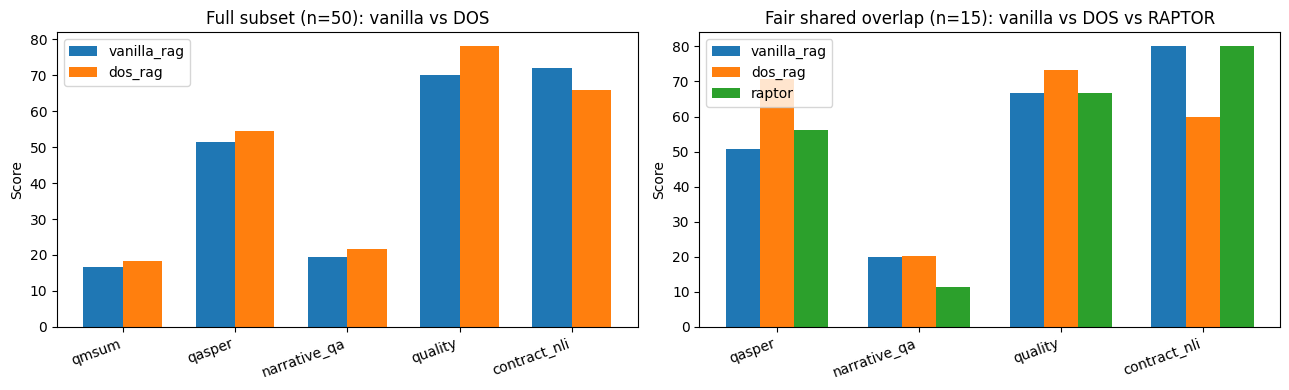

In [7]:
plot_rows = []
for task in ["qasper", "narrative_qa", "quality", "contract_nli"]:
    shared = raptor_shared_scores[task]
    plot_rows.extend(
        [
            {"task": task, "method": "vanilla_rag", "score": shared["vanilla_rag_shared15"]},
            {"task": task, "method": "dos_rag", "score": shared["dos_rag_shared15"]},
            {"task": task, "method": "raptor", "score": shared["raptor_shared15"]},
        ]
    )
plot_df = pd.DataFrame(plot_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

full_plot = pd.DataFrame(
    [
        {"task": task, "method": "vanilla_rag", "score": full_subset_scores["vanilla_rag"][task]}
        for task in ["qmsum", "qasper", "narrative_qa", "quality", "contract_nli"]
    ]
    + [
        {"task": task, "method": "dos_rag", "score": full_subset_scores["dos_rag"][task]}
        for task in ["qmsum", "qasper", "narrative_qa", "quality", "contract_nli"]
    ]
)
for idx, method in enumerate(["vanilla_rag", "dos_rag"]):
    method_rows = full_plot[full_plot["method"] == method]
    axes[0].bar([i + (idx - 0.5) * 0.35 for i in range(len(method_rows))], method_rows["score"], width=0.35, label=method)
axes[0].set_xticks(list(range(len(method_rows))))
axes[0].set_xticklabels(method_rows["task"].tolist(), rotation=20, ha="right")
axes[0].set_ylabel("Score")
axes[0].set_title("Full subset (n=50): vanilla vs DOS")
axes[0].legend()

for idx, method in enumerate(["vanilla_rag", "dos_rag", "raptor"]):
    method_rows = plot_df[plot_df["method"] == method]
    axes[1].bar([i + (idx - 1) * 0.24 for i in range(len(method_rows))], method_rows["score"], width=0.24, label=method)
axes[1].set_xticks(list(range(len(method_rows))))
axes[1].set_xticklabels(method_rows["task"].tolist(), rotation=20, ha="right")
axes[1].set_ylabel("Score")
axes[1].set_title("Fair shared overlap (n=15): vanilla vs DOS vs RAPTOR")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Written Analysis

### A. Is DOS basically long-context here?

Mostly **yes on some tasks, no on others**.

From the saved subset runs:

- `qasper`, `quality`, and `contract_nli` have very high token-span overlap between DOS and vanilla (`coverage_iou` around `0.98` to `0.99`).
- On those same tasks, both methods also cover almost the whole document.
- So on those tasks the current benchmark is **not primarily a missing-evidence story**. It is much closer to:
  - DOS: near-whole-document context in document order
  - vanilla: near-whole-document context in retrieval-rank order

That means the main difference being tested there is **ordering**, not access to different content.

### B. Why the older notebook display was misleading

Showing only the first retrieved chunk made DOS and vanilla look more similar than they really are.

That happened because:

- DOS and vanilla can still retrieve many of the same high-similarity chunks
- but DOS then reorders the selected context into source order
- vanilla leaves the context in retrieval-rank order

So the first retrieved chunk can match while the **prompt sequence** is completely different.

### C. Which tasks are mostly about ordering?

The strongest ordering-dominated tasks in the saved subset are:

- `qasper`
- `quality`
- `contract_nli`

Why:

- token coverage is already near-full
- DOS / vanilla coverage overlap is already near-total
- DOS prompt order is perfectly document-ordered (`1.0` by construction)
- vanilla prompt order is much less document-like

`qmsum` is close to this regime too, though not as completely collapsed as the three tasks above.

### D. Which task is still a real retrieval test?

`narrative_qa` is the clearest remaining retrieval regime.

Why:

- both methods only cover about one-third of the document on average
- DOS / vanilla token-span overlap drops a lot relative to the other tasks
- so both **which evidence is retrieved** and **how it is ordered** still matter there

### E. Task-type fit by method

#### `dos_rag`

DOS looks strongest on tasks that benefit from restoring a readable source narrative over broad coverage:

- `qasper`: best full-subset score among DOS / vanilla, and best fair shared-15 score vs RAPTOR
- `quality`: biggest DOS gain over vanilla on the full subset
- `qmsum`: modest DOS gain over vanilla under broad context coverage

Interpretation:

- these tasks appear to reward reading the evidence in a coherent source sequence once enough of the document is present

#### `vanilla_rag`

Vanilla looks best on tasks where a short, local clue should be front-loaded rather than buried in document order:

- `contract_nli`: vanilla beats DOS on the full subset, and ties RAPTOR on the fair shared-15 overlap
- some `qasper` examples also show vanilla doing better when the answer is a very precise short span and DOS drifts into a longer paraphrase

Interpretation:

- clause-local legal classification and precise short-span extraction seem more compatible with retrieval-rank ordering than with source-order restoration

#### `raptor`

RAPTOR is mixed but not uniformly bad:

- competitive on `qasper` in the fair shared overlap
- ties vanilla on `contract_nli` shared overlap
- clearly weak on `narrative_qa` in the saved run
- dramatically slower than both vanilla and DOS

This suggests, as an inference from the saved results, that hierarchical compression may preserve some high-level factual or legal signals, but can lose too much fine-grained narrative state for story QA.

### F. What this means for your research claim

The saved subset results support a **narrower and cleaner** claim than "DOS retrieval is better":

- On several tasks, DOS is winning even when it covers almost the same document content as vanilla.
- Therefore the gain is plausibly coming from **document-order restoration during reading**, not from retrieving fundamentally different evidence.
- The main counterexample is `contract_nli`, where restoring source order can hurt when the task is clause-local and label-based.

That is exactly why `reorder_only_rag` is the right next ablation: it can isolate ordering from differences in chunking and retrieval coverage.
